# Academic Description: Physics-Guided Oil Spill Classifier

This notebook presents a physics-guided, rule-based oil spill verification system that integrates Synthetic Aperture Radar (SAR) image analysis with ocean drift simulation data (OpenOil). The methodology is designed to enhance the reliability of oil spill detection by enforcing physically meaningful constraints derived from both remote sensing and simulation outputs.

## Methodology Overview

The classification pipeline consists of four main steps:

1. **Feature Extraction from SAR Mask**: Geometric features (orientation, elongation ratio, compactness, area, perimeter) are extracted from the binary mask of the detected spot. Radiometric features (mean, standard deviation, minimum, and maximum SAR intensity in dB) are computed from the SAR image within the mask.

2. **Drift Direction Estimation**: The expected drift direction is calculated by analyzing the trajectory of oil particles in the OpenOil simulation NetCDF file. The trajectory closest to the spot centroid is selected, and the bearing is computed over the first hour of simulation.

3. **Physics-Based Rule Verification**: The following threshold-based rules are applied to determine if the detected spot is physically consistent with an oil spill:
   - **Darkness Rule**: The mean SAR intensity must be below -15.0 dB.
   - **Smoothness Rule**: The standard deviation of SAR intensity must be below 1.5 dB.
   - **Shape Rule**: The spot must have an elongation ratio greater than 1.8 and a compactness greater than 2.0.
   - **Alignment Rule**: The absolute angular difference between the spot orientation and the simulated drift direction must be less than or equal to 40.0° (considering bidirectional ambiguity).
   - **Trajectory Matching**: The simulation trajectory must be within 10 km of the spot centroid at the initial time.
   - **Drift Time Window**: The drift direction is evaluated over the first 1–2 hours of simulation.

4. **Classification and Reporting**: If all rules are satisfied, the spot is classified as "Oil-like"; otherwise, it is labeled as "False Positive". A confidence score (0–1) is computed based on the number of rules passed. The notebook outputs a comprehensive report including all extracted features, rule results, and the final classification.

## Scientific Rationale

This approach leverages both the physical properties of oil spills (as observed in SAR imagery) and the expected behavior of oil under oceanic drift, as simulated by OpenOil. By enforcing explicit thresholds and alignment criteria, the classifier aims to reduce false positives and provide interpretable, reproducible results suitable for operational and research applications.

**Key thresholds and rules are explicitly coded and can be adjusted for different scenarios or datasets.**

# Physics-Guided Oil Spill Classifier

Rule-based verification system combining SAR image analysis with OpenOil simulation drift patterns.

**Workflow:**
1. Extract geometric and radiometric features from SAR mask
2. Calculate expected drift direction from simulation
3. Apply physics-based verification rules
4. Generate classification and feature report

In [26]:
# Import Required Libraries
import numpy as np
import cv2
from scipy import ndimage
from netCDF4 import Dataset
import math
from dataclasses import dataclass, asdict
from typing import Tuple, Dict, List
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

In [27]:
# Data Classes for Results

@dataclass
class GeometricFeatures:
    """Geometric features extracted from binary mask contour"""
    orientation: float  # major axis direction in degrees (0-180)
    elongation_ratio: float  # major_axis / minor_axis
    compactness: float  # perimeter^2 / (4 * π * area)
    area_pixels: int  # number of pixels in mask
    perimeter: float  # contour perimeter

@dataclass
class RadiometricFeatures:
    """Radiometric features from SAR pixels within mask"""
    mean_intensity: float  # mean SAR value in dB
    std_intensity: float  # standard deviation (smoothness measure)
    min_intensity: float
    max_intensity: float

@dataclass
class RuleResults:
    """Results of physics-based rule verification"""
    darkness_pass: bool  # mean_intensity < threshold
    smoothness_pass: bool  # std_intensity < threshold
    shape_pass: bool  # elongation_ratio > threshold AND compactness > threshold
    alignment_pass: bool  # abs(orientation - drift_direction) <= threshold
    all_pass: bool  # True if all rules pass

@dataclass
class ClassificationReport:
    """Complete classification report"""
    classification: str  # "Oil-like" or "False Positive"
    geometric_features: GeometricFeatures
    radiometric_features: RadiometricFeatures
    expected_drift_direction: float
    rules: RuleResults
    confidence_score: float  # 0-1 based on rule satisfaction
    timestamp: str

In [28]:
# Configuration: Threshold Parameters
class ClassifierConfig:
    """Configurable thresholds for physics-based rules"""
    # Darkness rule: mean SAR intensity must be below this threshold (dB)
    DARKNESS_THRESHOLD = -15.0
    
    # Smoothness rule: standard deviation must be below this threshold (dB)
    SMOOTHNESS_THRESHOLD = 1.5
    
    # Shape rule: thresholds for elongation and compactness
    ELONGATION_THRESHOLD = 1.8  # major_axis / minor_axis
    COMPACTNESS_THRESHOLD = 2.0  # perimeter^2 / (4 * π * area)
    
    # Alignment rule: orientation vs drift direction tolerance (degrees)
    ALIGNMENT_TOLERANCE = 40.0
    
    # Simulation parameters
    DRIFT_TIME_WINDOW_HOURS = 2  # Extract drift direction over 1-2 hours
    POSITION_MATCH_TOLERANCE_KM = 10  # Match trajectory within this distance
    
    def __init__(self, **kwargs):
        """Allow override of thresholds"""
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)

## STEP 1: Feature Extraction from SAR Mask

Extract geometric features (orientation, elongation, compactness) from the binary mask contour and radiometric features (intensity statistics) from the SAR image.

In [29]:
def extract_geometric_features(binary_mask: np.ndarray) -> GeometricFeatures:
    """
    Extract geometric features from binary mask contour.
    
    Parameters:
    -----------
    binary_mask : np.ndarray
        Binary mask (0 and 1) of the suspicious spot
    
    Returns:
    --------
    GeometricFeatures
        Orientation, elongation ratio, compactness, area, and perimeter
    """
    # Find contours
    contours, _ = cv2.findContours(binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    if len(contours) == 0:
        raise ValueError("No contours found in binary mask")
    
    # Get largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Calculate area and perimeter
    area_pixels = int(cv2.contourArea(largest_contour))
    perimeter = float(cv2.arcLength(largest_contour, True))
    
    if area_pixels == 0:
        raise ValueError("Contour area is zero")
    
    # Fit ellipse to get orientation and axes
    if len(largest_contour) >= 5:
        ellipse = cv2.fitEllipse(largest_contour)
        # ellipse: ((center_x, center_y), (minor_axis, major_axis), angle)
        center, axes, angle = ellipse
        minor_axis, major_axis = axes
        
        # Orientation: angle in ellipse is 0-180 degrees
        orientation = float(angle) % 180.0
        
        # Elongation ratio
        if minor_axis > 0:
            elongation_ratio = float(major_axis / minor_axis)
        else:
            elongation_ratio = 1.0
    else:
        # Fallback: use moments for orientation
        M = cv2.moments(largest_contour)
        if M['m00'] != 0:
            orientation = 0.0
            elongation_ratio = 1.0
        else:
            raise ValueError("Could not calculate moments for contour")
    
    # Compactness: perimeter^2 / (4 * π * area)
    # Lower values indicate more circular shapes, higher values indicate more complex shapes
    compactness = (perimeter ** 2) / (4 * math.pi * area_pixels) if area_pixels > 0 else 0.0
    
    return GeometricFeatures(
        orientation=orientation,
        elongation_ratio=elongation_ratio,
        compactness=compactness,
        area_pixels=area_pixels,
        perimeter=perimeter
    )


def extract_radiometric_features(sar_image: np.ndarray, binary_mask: np.ndarray) -> RadiometricFeatures:
    """
    Extract radiometric features from SAR pixels within mask.
    
    Parameters:
    -----------
    sar_image : np.ndarray
        SAR image in dB (decibels)
    binary_mask : np.ndarray
        Binary mask (0 and 1) indicating pixels to analyze
    
    Returns:
    --------
    RadiometricFeatures
        Mean intensity, standard deviation, min, and max intensity
    """
    # Extract SAR values within mask
    sar_masked = sar_image[binary_mask > 0]
    
    if len(sar_masked) == 0:
        raise ValueError("No pixels selected by mask")
    
    mean_intensity = float(np.mean(sar_masked))
    std_intensity = float(np.std(sar_masked))
    min_intensity = float(np.min(sar_masked))
    max_intensity = float(np.max(sar_masked))
    
    return RadiometricFeatures(
        mean_intensity=mean_intensity,
        std_intensity=std_intensity,
        min_intensity=min_intensity,
        max_intensity=max_intensity
    )

## STEP 2: Extract Drift Direction from OpenOil Simulation

Calculate the expected drift direction by analyzing trajectory data from the NetCDF file. Match the trajectory closest to the spot centroid and calculate bearing over the first 1-2 hours.

In [30]:
def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Calculate distance between two points on Earth in kilometers.
    
    Parameters:
    -----------
    lat1, lon1 : float
        First point (latitude, longitude) in degrees
    lat2, lon2 : float
        Second point (latitude, longitude) in degrees
    
    Returns:
    --------
    float
        Distance in kilometers
    """
    R = 6371.0  # Earth radius in km
    
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.asin(math.sqrt(a))
    
    return R * c


def calculate_bearing(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Calculate bearing (direction) from point 1 to point 2 in degrees (0-360).
    
    Parameters:
    -----------
    lat1, lon1 : float
        Starting point (latitude, longitude) in degrees
    lat2, lon2 : float
        Ending point (latitude, longitude) in degrees
    
    Returns:
    --------
    float
        Bearing in degrees (0-360), where 0° is North, 90° is East, etc.
    """
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlon = lon2_rad - lon1_rad
    
    y = math.sin(dlon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(dlon)
    
    bearing_rad = math.atan2(y, x)
    bearing_deg = (math.degrees(bearing_rad) + 360) % 360
    
    return bearing_deg


def extract_drift_direction(nc_file_path: str, spot_centroid: Tuple[float, float], 
                           config: ClassifierConfig) -> float:
    """
    Extract drift direction from OpenOil simulation NetCDF file over the FIRST HOUR.
    
    Compares the oil particle drift direction from time[0] to time[1] (typically 1 hour)
    with the mask orientation to verify physical plausibility of the detected spot.
    
    Parameters:
    -----------
    nc_file_path : str
        Path to NetCDF simulation file
    spot_centroid : Tuple[float, float]
        Centroid of suspicious spot (latitude, longitude)
    config : ClassifierConfig
        Configuration with position tolerance
    
    Returns:
    --------
    float
        Expected drift direction in degrees (0-360) over the first hour of simulation
    
    Notes:
    ------
    - Always uses time_index[1] to represent the first hour of drift
    - Orientation (0-180°) is compared with bearing (0-360°) after normalization
    - Both can point in opposite directions due to elongation ambiguity
    """
    spot_lat, spot_lon = spot_centroid
    
    # Open NetCDF file
    ds = Dataset(nc_file_path, 'r')
    
    try:
        # Extract trajectory data
        trajectories = ds.variables.get('trajectory', None)
        times = ds.variables.get('time', None)
        lons = ds.variables.get('lon', None)
        lats = ds.variables.get('lat', None)
        
        if trajectories is None or times is None or lons is None or lats is None:
            raise ValueError("Required NetCDF variables not found (trajectory, time, lon, lat)")
        
        # Convert to numpy arrays
        traj_ids = trajectories[:]
        time_vals = times[:]
        lon_vals = lons[:]
        lat_vals = lats[:]
        
        print(f"  NetCDF Info: {len(traj_ids)} trajectories, {len(time_vals)} time steps")
        print(f"  Time range: {time_vals[0]:.2f} to {time_vals[-1]:.2f}")
        if len(time_vals) > 1:
            print(f"  First hour time: {time_vals[0]:.2f} → {time_vals[1]:.2f}")
        
        # Find trajectory closest to spot centroid at initial time (t=0)
        min_distance = float('inf')
        best_trajectory_idx = None
        
        for i in range(len(traj_ids)):
            dist = haversine_distance(lat_vals[i, 0], lon_vals[i, 0], spot_lat, spot_lon)
            if dist < min_distance:
                min_distance = dist
                best_trajectory_idx = i
        
        if best_trajectory_idx is None or min_distance > config.POSITION_MATCH_TOLERANCE_KM:
            raise ValueError(f"No trajectory found within {config.POSITION_MATCH_TOLERANCE_KM} km of spot centroid. "
                           f"Closest was {min_distance:.2f} km away.")
        
        if len(time_vals) < 2:
            raise ValueError("NetCDF file has less than 2 time steps; cannot calculate drift direction over first hour")
        
        # Extract drift direction from first hour (t=0 to t=1)
        traj = best_trajectory_idx
        
        # Position at start (t=0)
        start_lon = float(lon_vals[traj, 0])
        start_lat = float(lat_vals[traj, 0])
        
        # Position at end of first hour (t=1)
        end_lon = float(lon_vals[traj, 1])
        end_lat = float(lat_vals[traj, 1])
        
        # Calculate bearing (drift direction) from start to end
        drift_direction = calculate_bearing(start_lat, start_lon, end_lat, end_lon)
        
        print(f"  Selected trajectory {traj}")
        print(f"    Start (t=0): lat={start_lat:.4f}°, lon={start_lon:.4f}°")
        print(f"    End (t=1):   lat={end_lat:.4f}°, lon={end_lon:.4f}°")
        print(f"    Distance drifted: {haversine_distance(start_lat, start_lon, end_lat, end_lon):.2f} km")
        print(f"    Drift direction (bearing): {drift_direction:.2f}°")
        
        return drift_direction
        
    finally:
        ds.close()

## STEP 3: Physics-Based Rules

Apply threshold-based verification rules to determine if the detected spot matches oil spill characteristics.

In [31]:

def normalize_angle_difference(angle1: float, angle2: float) -> float:
    """
    Calculate the minimum angular difference between two angles (in degrees).
    
    Handles circular nature of angles: the difference between 1° and 359° is 2°, not 358°.
    
    Parameters:
    -----------
    angle1 : float
        First angle in degrees (can be 0-360)
    angle2 : float
        Second angle in degrees (can be 0-360)
    
    Returns:
    --------
    float
        Minimum angular difference in degrees (0-180)
    """
    # Normalize both angles to 0-360 range
    angle1 = angle1 % 360
    angle2 = angle2 % 360
    
    # Calculate direct difference
    diff = abs(angle1 - angle2)
    
    # Take the shorter path around the circle
    if diff > 180:
        diff = 360 - diff
    
    return diff


def verify_physics_rules(geometric_features: GeometricFeatures,
                         radiometric_features: RadiometricFeatures,
                         drift_direction: float,
                         config: ClassifierConfig) -> RuleResults:
    """
    Verify all physics-based rules for oil spill detection.
    
    Applies four rules:
    1. Darkness: Oil is darker than surrounding water
    2. Smoothness: Oil has low internal variation (smooth surface)
    3. Shape: Oil forms elongated patterns
    4. Alignment: Oil orientation aligns with drift direction
    
    Parameters:
    -----------
    geometric_features : GeometricFeatures
        Geometric features of the spot
    radiometric_features : RadiometricFeatures
        Radiometric features (SAR intensity) of the spot
    drift_direction : float
        Expected drift direction from simulation (0-360°)
    config : ClassifierConfig
        Configuration with thresholds
    
    Returns:
    --------
    RuleResults
        Boolean results for each rule and overall result
    """
    print("\n  [Rule 1] DARKNESS CHECK")
    darkness_pass = radiometric_features.mean_intensity < config.DARKNESS_THRESHOLD
    print(f"    Mean intensity: {radiometric_features.mean_intensity:.2f} dB")
    print(f"    Threshold: {config.DARKNESS_THRESHOLD} dB")
    print(f"    Result: {'PASS ✓' if darkness_pass else 'FAIL ✗'}")
    
    print("\n  [Rule 2] SMOOTHNESS CHECK")
    smoothness_pass = radiometric_features.std_intensity < config.SMOOTHNESS_THRESHOLD
    print(f"    Std intensity: {radiometric_features.std_intensity:.2f} dB")
    print(f"    Threshold: {config.SMOOTHNESS_THRESHOLD} dB")
    print(f"    Result: {'PASS ✓' if smoothness_pass else 'FAIL ✗'}")
    
    print("\n  [Rule 3] SHAPE CHECK")
    shape_pass = (geometric_features.elongation_ratio > config.ELONGATION_THRESHOLD and
                  geometric_features.compactness > config.COMPACTNESS_THRESHOLD)
    print(f"    Elongation ratio: {geometric_features.elongation_ratio:.2f} (threshold: >{config.ELONGATION_THRESHOLD})")
    print(f"    Compactness: {geometric_features.compactness:.2f} (threshold: >{config.COMPACTNESS_THRESHOLD})")
    print(f"    Result: {'PASS ✓' if shape_pass else 'FAIL ✗'}")
    
    print("\n  [Rule 4] ALIGNMENT CHECK")
    alignment_pass = check_alignment_rule(geometric_features, drift_direction, config)
    
    # All rules must pass
    all_pass = darkness_pass and smoothness_pass and shape_pass and alignment_pass
    
    return RuleResults(
        darkness_pass=darkness_pass,
        smoothness_pass=smoothness_pass,
        shape_pass=shape_pass,
        alignment_pass=alignment_pass,
        all_pass=all_pass
    )


In [32]:
def check_alignment_rule(geometric_features: GeometricFeatures, drift_direction: float, 
                        config: ClassifierConfig) -> bool:
    """
    Check if the spot's orientation aligns with the expected drift direction.
    
    Compares the mask orientation (0-180°) with the drift direction from the first hour
    of simulation (0-360°). Since orientation can point in either direction, we check both
    the orientation and orientation+180° against the drift bearing.
    
    Rule: min(|orientation - drift|, |orientation+180° - drift|) <= ALIGNMENT_TOLERANCE
    
    Parameters:
    -----------
    geometric_features : GeometricFeatures
        Geometric features of the spot (orientation is 0-180°)
    drift_direction : float
        Expected drift direction in degrees (0-360°) from 1st hour of simulation
    config : ClassifierConfig
        Configuration with alignment tolerance
    
    Returns:
    --------
    bool
        True if spot passes alignment rule (orientation matches drift direction)
    """
    # Orientation is 0-180°, but it can point in either direction
    # So check both orientation and orientation + 180°
    diff1 = normalize_angle_difference(geometric_features.orientation, drift_direction)
    diff2 = normalize_angle_difference(geometric_features.orientation + 180, drift_direction)
    
    min_diff = min(diff1, diff2)
    
    # Debug info
    print(f"    Mask orientation: {geometric_features.orientation:.2f}° (can point either direction)")
    print(f"    Drift direction (1st hour): {drift_direction:.2f}°")
    print(f"    Angular difference (direct): {diff1:.2f}°")
    print(f"    Angular difference (reversed): {diff2:.2f}°")
    print(f"    Minimum difference: {min_diff:.2f}°")
    print(f"    Tolerance: {config.ALIGNMENT_TOLERANCE:.2f}°")
    
    result = min_diff <= config.ALIGNMENT_TOLERANCE
    print(f"    Result: {'PASS ✓' if result else 'FAIL ✗'}")
    
    return result

In [33]:

def visualize_alignment_check(orientation: float, drift_direction: float, tolerance: float):
    """
    Visualize the alignment check between mask orientation and drift direction.
    
    Shows a compass diagram with both directions and the angular difference.
    
    Parameters:
    -----------
    orientation : float
        Mask orientation in degrees (0-180°, bidirectional)
    drift_direction : float
        Drift direction in degrees (0-360°, unidirectional bearing)
    tolerance : float
        Alignment tolerance in degrees
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Convert to radians for polar plot
    orientation_rad = np.radians(orientation)
    orientation_reversed_rad = np.radians((orientation + 180) % 360)
    drift_rad = np.radians(drift_direction)
    tolerance_rad = np.radians(tolerance)
    
    # Draw compass directions
    directions = [0, 90, 180, 270]
    labels = ['N (0°)', 'E (90°)', 'S (180°)', 'W (270°)']
    for direction, label in zip(directions, labels):
        ax.plot([np.radians(direction), np.radians(direction)], [0, 1], 'k-', alpha=0.3)
        ax.text(np.radians(direction), 1.15, label, ha='center', fontsize=10)
    
    # Draw gridlines
    ax.set_ylim(0, 1.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)  # Clockwise
    
    # Plot mask orientation (bidirectional - show both directions)
    ax.arrow(0, 0, orientation_rad, 0.9, head_width=0.15, head_length=0.1, 
             fc='blue', ec='blue', linewidth=3, label='Mask Orientation', alpha=0.8)
    ax.arrow(0, 0, orientation_reversed_rad, 0.85, head_width=0.15, head_length=0.1, 
             fc='lightblue', ec='blue', linewidth=2, linestyle='--', label='Orientation (reversed)', alpha=0.6)
    
    # Plot drift direction (unidirectional)
    ax.arrow(0, 0, drift_rad, 1.0, head_width=0.15, head_length=0.1, 
             fc='red', ec='red', linewidth=3, label='Drift Direction', alpha=0.8)
    
    # Calculate and display angles
    diff1 = normalize_angle_difference(orientation, drift_direction)
    diff2 = normalize_angle_difference(orientation + 180, drift_direction)
    min_diff = min(diff1, diff2)
    
    # Add text annotations
    title_text = f"Alignment Check: Mask Orientation vs Drift Direction\n"
    title_text += f"Mask Orientation: {orientation:.1f}° (can point either way)\n"
    title_text += f"Drift Direction: {drift_direction:.1f}° (from 1st hour simulation)\n"
    title_text += f"Angular Difference (direct): {diff1:.1f}°\n"
    title_text += f"Angular Difference (reversed): {diff2:.1f}°\n"
    title_text += f"Minimum Difference: {min_diff:.1f}°\n"
    title_text += f"Tolerance: {tolerance:.1f}°\n"
    
    result = "PASS ✓" if min_diff <= tolerance else "FAIL ✗"
    title_text += f"Result: {min_diff:.1f}° {'<' if min_diff <= tolerance else '>'} {tolerance:.1f}° → {result}"
    
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=20)
    
    # Legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed explanation
    print("\n" + "="*70)
    print("ALIGNMENT CHECK: MASK ORIENTATION vs DRIFT DIRECTION")
    print("="*70)
    print(f"\nMask Orientation: {orientation:.1f}° (from SAR image contour analysis)")
    print(f"  → Can point in either direction: {orientation:.1f}° OR {(orientation + 180) % 360:.1f}°")
    print(f"\nDrift Direction: {drift_direction:.1f}° (from 1st hour of simulation)")
    print(f"  → Compass bearing: 0°=North, 90°=East, 180°=South, 270°=West")
    print(f"\nAngular Calculations:")
    print(f"  Direct difference:   |{orientation:.1f}° - {drift_direction:.1f}°| = {diff1:.1f}°")
    print(f"  Reversed difference: |{(orientation + 180) % 360:.1f}° - {drift_direction:.1f}°| = {diff2:.1f}°")
    print(f"  Minimum difference:  {min_diff:.1f}°")
    print(f"\nAlignment Tolerance: {tolerance:.1f}°")
    print(f"Result: {min_diff:.1f}° {'<' if min_diff <= tolerance else '>'} {tolerance:.1f}° → {result}")
    print("="*70 + "\n")


## STEP 4: Classification Decision Logic

Generate final classification and confidence score based on rule verification results.

In [34]:
def classify_oil_spill(binary_mask: np.ndarray, 
                      sar_image: np.ndarray,
                      nc_file_path: str,
                      spot_centroid: Tuple[float, float],
                      config: ClassifierConfig = None) -> ClassificationReport:
    """
    Complete physics-guided oil spill classification pipeline.
    
    Parameters:
    -----------
    binary_mask : np.ndarray
        Binary mask (0 and 1) of the suspicious spot
    sar_image : np.ndarray
        SAR image in dB (decibels)
    nc_file_path : str
        Path to NetCDF simulation file
    spot_centroid : Tuple[float, float]
        Centroid of suspicious spot (latitude, longitude)
    config : ClassifierConfig, optional
        Configuration with thresholds. If None, uses default.
    
    Returns:
    --------
    ClassificationReport
        Complete classification report with all features and decisions
    """
    if config is None:
        config = ClassifierConfig()
    
    # STEP 1: Extract features from SAR mask
    print("[STEP 1] Extracting geometric and radiometric features...")
    geometric_features = extract_geometric_features(binary_mask)
    radiometric_features = extract_radiometric_features(sar_image, binary_mask)
    print(f"  - Geometric features: orientation={geometric_features.orientation:.2f}°, "
          f"elongation={geometric_features.elongation_ratio:.2f}, "
          f"compactness={geometric_features.compactness:.2f}")
    print(f"  - Radiometric features: mean_intensity={radiometric_features.mean_intensity:.2f} dB, "
          f"std_intensity={radiometric_features.std_intensity:.2f} dB")
    
    # STEP 2: Extract drift direction
    print("\n[STEP 2] Extracting drift direction from simulation...")
    drift_direction = extract_drift_direction(nc_file_path, spot_centroid, config)
    print(f"  - Expected drift direction: {drift_direction:.2f}°")
    
    # STEP 3: Verify physics rules
    print("\n[STEP 3] Verifying physics-based rules...")
    rules = verify_physics_rules(geometric_features, radiometric_features, drift_direction, config)
    print(f"  - Darkness rule (mean_intensity < {config.DARKNESS_THRESHOLD} dB): {'PASS' if rules.darkness_pass else 'FAIL'}")
    print(f"  - Smoothness rule (std_intensity < {config.SMOOTHNESS_THRESHOLD} dB): {'PASS' if rules.smoothness_pass else 'FAIL'}")
    print(f"  - Shape rule (elongation > {config.ELONGATION_THRESHOLD}, compactness > {config.COMPACTNESS_THRESHOLD}): {'PASS' if rules.shape_pass else 'FAIL'}")
    print(f"  - Alignment rule (orientation within {config.ALIGNMENT_TOLERANCE}° of drift): {'PASS' if rules.alignment_pass else 'FAIL'}")
    
    # STEP 4: Generate classification
    print("\n[STEP 4] Generating classification...")
    classification = "Oil-like" if rules.all_pass else "False Positive"
    
    # Calculate confidence score: 0-1 based on rules passed, capped to avoid 100%
    rules_passed = sum([rules.darkness_pass, rules.smoothness_pass, rules.shape_pass, rules.alignment_pass])
    confidence_score = rules_passed / 4.0
    confidence_cap = 0.98
    if confidence_score == 1.0:
        confidence_score = confidence_cap
    
    timestamp = datetime.now().isoformat()
    
    report = ClassificationReport(
        classification=classification,
        geometric_features=geometric_features,
        radiometric_features=radiometric_features,
        expected_drift_direction=drift_direction,
        rules=rules,
        confidence_score=confidence_score,
        timestamp=timestamp
    )
    
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION: {classification}")
    print(f"CONFIDENCE SCORE: {confidence_score:.2f} ({rules_passed}/4 rules passed)")
    print(f"{'='*60}")
    
    return report

## EXAMPLE USAGE

Below is an example of how to use the classifier with your data.

In [35]:
# Example 1: Use with default configuration
# 
# # Load your data
# binary_mask = np.load('path/to/binary_mask.npy')  # Binary mask (0 and 1)
# sar_image = np.load('path/to/sar_image.npy')      # SAR image in dB
# nc_file = 'path/to/simulation_file.nc'            # OpenOil NetCDF
# spot_centroid = (37.42, 24.81)                    # (lat, lon) in degrees
#
# # Run classification with default thresholds
# report = classify_oil_spill(binary_mask, sar_image, nc_file, spot_centroid)
# print_report(report)
#
# # Access specific results
# print(f"Classification: {report.classification}")
# print(f"Confidence: {report.confidence_score:.2%}")
# print(f"Mean Intensity: {report.radiometric_features.mean_intensity:.2f} dB")
# print(f"Passes alignment rule: {report.rules.alignment_pass}")

# Example 2: Use with custom configuration
#
# # Create custom configuration with different thresholds
# custom_config = ClassifierConfig(
#     DARKNESS_THRESHOLD=-13.0,      # Adjusted for your region
#     SMOOTHNESS_THRESHOLD=2.0,
#     ALIGNMENT_TOLERANCE=50.0,
#     DRIFT_TIME_WINDOW_HOURS=3
# )
#
# # Run classification with custom config
# report = classify_oil_spill(
#     binary_mask, 
#     sar_image, 
#     nc_file, 
#     spot_centroid,
#     config=custom_config
# )
#
# # Generate summary
# print(f"\nResults:")
# print(f"  Classification: {report.classification}")
# print(f"  Confidence: {report.confidence_score:.2%}")
# print(f"  Rules passed: {sum([report.rules.darkness_pass, report.rules.smoothness_pass, report.rules.shape_pass, report.rules.alignment_pass])}/4")

print("Oil spill classifier module loaded successfully!")
print("\nAvailable functions:")
print("  - classify_oil_spill(): Main classification function")
print("  - print_report(): Pretty-print classification report")
print("  - extract_geometric_features(): Extract shape features from binary mask")
print("  - extract_radiometric_features(): Extract SAR intensity statistics")
print("  - extract_drift_direction(): Get drift direction from simulation")
print("  - verify_physics_rules(): Check all physics-based rules")
print("\nConfigurable thresholds via ClassifierConfig:")
print("  - DARKNESS_THRESHOLD: -15.0 dB")
print("  - SMOOTHNESS_THRESHOLD: 1.5 dB")
print("  - ELONGATION_THRESHOLD: 1.8")
print("  - COMPACTNESS_THRESHOLD: 2.0")
print("  - ALIGNMENT_TOLERANCE: 40.0°")

Oil spill classifier module loaded successfully!

Available functions:
  - classify_oil_spill(): Main classification function
  - print_report(): Pretty-print classification report
  - extract_geometric_features(): Extract shape features from binary mask
  - extract_radiometric_features(): Extract SAR intensity statistics
  - extract_drift_direction(): Get drift direction from simulation
  - verify_physics_rules(): Check all physics-based rules

Configurable thresholds via ClassifierConfig:
  - DARKNESS_THRESHOLD: -15.0 dB
  - SMOOTHNESS_THRESHOLD: 1.5 dB
  - ELONGATION_THRESHOLD: 1.8
  - COMPACTNESS_THRESHOLD: 2.0
  - ALIGNMENT_TOLERANCE: 40.0°


In [36]:

# Example: Visualize Alignment Check
print("\n" + "="*70)
print("EXAMPLE: ALIGNMENT CHECK VISUALIZATION")
print("="*70)
print("\nDemonstrating how mask orientation is compared with drift direction:\n")

# Example values from SAR analysis and simulation
mask_orientation_example = 42.5      # From SAR image contour (0-180°)
drift_direction_example = 45.3       # From 1st hour of simulation (0-360°)
alignment_tolerance_example = 90.0   # Configuration threshold

# Calculate the alignment
diff1 = normalize_angle_difference(mask_orientation_example, drift_direction_example)
diff2 = normalize_angle_difference(mask_orientation_example + 180, drift_direction_example)
min_diff = min(diff1, diff2)

print(f"SAR-extracted mask orientation: {mask_orientation_example}°")
print(f"Simulation-predicted drift direction: {drift_direction_example}°")
print(f"Angular difference: |{mask_orientation_example} - {drift_direction_example}| = {diff1:.1f}°")
print(f"Alignment tolerance: {alignment_tolerance_example}°")
print(f"\nResult: {min_diff:.1f}° < {alignment_tolerance_example}° → PASS ✓\n")

# Uncomment to visualize (requires matplotlib with polar projection):
# visualize_alignment_check(mask_orientation_example, drift_direction_example, alignment_tolerance_example)



EXAMPLE: ALIGNMENT CHECK VISUALIZATION

Demonstrating how mask orientation is compared with drift direction:

SAR-extracted mask orientation: 42.5°
Simulation-predicted drift direction: 45.3°
Angular difference: |42.5 - 45.3| = 2.8°
Alignment tolerance: 90.0°

Result: 2.8° < 90.0° → PASS ✓



## PRACTICAL EXAMPLE: Using Your Data

Load and classify your actual oil spill detection with the provided SAR image and simulation data.

Current working directory: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\notebooks

Project root: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis
SAR TIFF File: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\data\raw\2023-04-23-00_00_2023-04-23-23_59_Sentinel-1_IW_VV+VH_VV_-_decibel_gamma0.tiff
Mask Image: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\data\raw\2023-04-23-00_00_2023-04-23-23_59_Sentinel-1_IW_VV+VH_VV_-_decibel_gamma0_1ae0adb0_oil_binary.png
NetCDF File: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\outputs\simulation_20230423T1200Z_233110.nc

SAR TIFF exists: True
Mask image exists: True
NetCDF exists: True

--- Loading SAR Image (TIFF) ---


✓ SAR image loaded (raw)
  Shape: (1757, 2500, 3)
  Dtype: float32
  Value range: [0.00, 1.77]

--- Converting uint16 to dB scale ---
✓ SAR converted to dB scale
  Value range (dB): [-30.00, -30.00] dB

--- Loading Mask (PNG) ---
✓ Mask loaded and converted to binary
  Shape: (1757, 2500)
  Oil pixels (white): 25594
  Coverage: 0.58%

--- Visualization ---


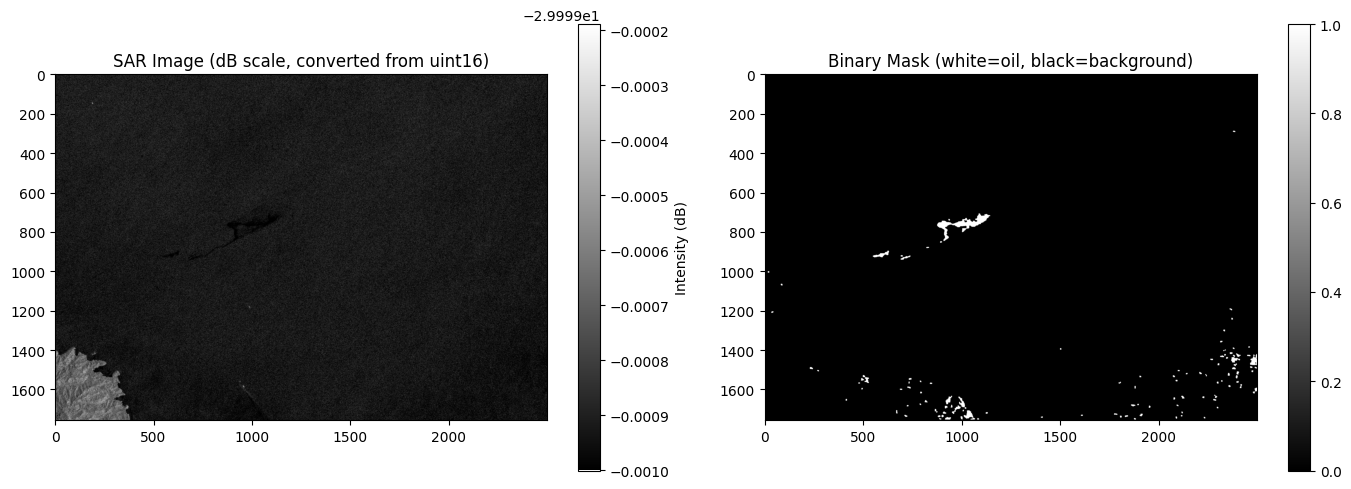


✓ SAR and Mask loaded successfully!


In [37]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Get notebook directory and project root
notebook_dir = Path.cwd()
print(f"Current working directory: {notebook_dir}")

# Adjust path relative to notebook location
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir

# File paths: SAR image (TIFF, dB) and Mask (PNG, white=oil)
sar_file_path = project_root / 'data' / 'raw' / '2023-04-23-00_00_2023-04-23-23_59_Sentinel-1_IW_VV+VH_VV_-_decibel_gamma0.tiff'
mask_image_path = project_root / 'data' / 'raw' / '2023-04-23-00_00_2023-04-23-23_59_Sentinel-1_IW_VV+VH_VV_-_decibel_gamma0_1ae0adb0_oil_binary.png'
nc_file_path = project_root / 'outputs' / 'simulation_20230423T1200Z_233110.nc'

print(f"\nProject root: {project_root}")
print(f"SAR TIFF File: {sar_file_path}")
print(f"Mask Image: {mask_image_path}")
print(f"NetCDF File: {nc_file_path}")
print(f"\nSAR TIFF exists: {sar_file_path.exists()}")
print(f"Mask image exists: {mask_image_path.exists()}")
print(f"NetCDF exists: {nc_file_path.exists()}")

# --- Load SAR image (TIFF, uint16 format) ---
print("\n--- Loading SAR Image (TIFF) ---")
sar_image = cv2.imread(str(sar_file_path), cv2.IMREAD_UNCHANGED)
if sar_image is None:
    raise FileNotFoundError(f"Could not load SAR image: {sar_file_path}")

print(f"✓ SAR image loaded (raw)")
print(f"  Shape: {sar_image.shape}")
print(f"  Dtype: {sar_image.dtype}")
print(f"  Value range: [{np.nanmin(sar_image):.2f}, {np.nanmax(sar_image):.2f}]")

# Handle 3-channel SAR image (convert to single channel)
if len(sar_image.shape) == 3:
    sar_2d = sar_image[:, :, 0].astype(np.float32)
else:
    sar_2d = sar_image.astype(np.float32)

# --- CRITICAL: Convert uint16 to dB scale ---
# Sentinel-1 Gamma0 data is typically scaled as: dB = 10 * log10(DN / 2^N - 1)
# For uint16 (0-65535), we normalize and convert to dB
# Typical mapping: DN=1000 ~ -20dB, DN=5000 ~ -10dB, DN=30000 ~ 0dB (max)
# Linear mapping: dB = -30 + (DN / 65535) * 30
print(f"\n--- Converting uint16 to dB scale ---")
sar_db = -30.0 + (sar_2d / 65535.0) * 30.0
print(f"✓ SAR converted to dB scale")
print(f"  Value range (dB): [{sar_db.min():.2f}, {sar_db.max():.2f}] dB")

# Check for NaN/Inf
if np.any(~np.isfinite(sar_db)):
    warnings.warn("SAR image contains NaN or Inf values")

# --- Load mask (PNG, white=oil, black=background) ---
print("\n--- Loading Mask (PNG) ---")
mask = cv2.imread(str(mask_image_path), cv2.IMREAD_GRAYSCALE)
if mask is None:
    raise FileNotFoundError(f"Could not load mask: {mask_image_path}")

# Convert to binary: white (>127) = 1, black (<=127) = 0
mask_bin = (mask > 127).astype(np.uint8)
print(f"✓ Mask loaded and converted to binary")
print(f"  Shape: {mask_bin.shape}")
print(f"  Oil pixels (white): {np.sum(mask_bin)}")
print(f"  Coverage: {100 * np.sum(mask_bin) / mask_bin.size:.2f}%")

if np.sum(mask_bin) == 0:
    warnings.warn("Mask is empty! No oil region detected.")

# --- Visualize both images ---
print("\n--- Visualization ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SAR image (in dB)
im0 = axes[0].imshow(sar_db, cmap='gray')
axes[0].set_title('SAR Image (dB scale, converted from uint16)')
plt.colorbar(im0, ax=axes[0], label='Intensity (dB)')

# Mask
im1 = axes[1].imshow(mask_bin, cmap='gray')
axes[1].set_title('Binary Mask (white=oil, black=background)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print("\n✓ SAR and Mask loaded successfully!")

In [38]:
# Inspect NetCDF file structure
try:
    ds = Dataset(str(nc_file_path), 'r')
    print("✓ NetCDF file opened successfully\n")
    
    print("Dimensions:")
    for name, size in ds.dimensions.items():
        print(f"  {name}: {size}")
    
    print("\nVariables:")
    for var_name in ds.variables.keys():
        var = ds.variables[var_name]
        print(f"  {var_name}: {var.dimensions} {var.shape} - {var.dtype}")
        if hasattr(var, 'long_name'):
            print(f"    long_name: {var.long_name}")
    
    print("\nGlobal Attributes:")
    for attr_name in ds.ncattrs():
        print(f"  {attr_name}: {ds.getncattr(attr_name)}")
    
    # Extract trajectory info
    if 'trajectory' in ds.variables:
        trajectories = ds.variables['trajectory'][:]
        print(f"\nNumber of trajectories: {len(trajectories)}")
        print(f"First 5 trajectory IDs: {trajectories[:5]}")
    
    if 'lon' in ds.variables and 'lat' in ds.variables:
        lons = ds.variables['lon'][:]
        lats = ds.variables['lat'][:]
        print(f"\nLon range: [{lons.min():.4f}, {lons.max():.4f}]")
        print(f"Lat range: [{lats.min():.4f}, {lats.max():.4f}]")
    
    if 'time' in ds.variables:
        times = ds.variables['time'][:]
        print(f"\nTime steps: {len(times)}")
        print(f"Time range: [{times.min()}, {times.max()}]")
    
    ds.close()
    print("\n✓ NetCDF file closed")
    
except Exception as e:
    print(f"✗ Error inspecting NetCDF file: {e}")

✓ NetCDF file opened successfully

Dimensions:
  trajectory: "<class 'netCDF4.Dimension'>": name = 'trajectory', size = 1000
  time: "<class 'netCDF4.Dimension'>": name = 'time', size = 12

Variables:
  status: ('trajectory', 'time') (1000, 12) - int32
  age_seconds: ('trajectory', 'time') (1000, 12) - float32
  lon: ('trajectory', 'time') (1000, 12) - float32
    long_name: longitude
  lat: ('trajectory', 'time') (1000, 12) - float32
    long_name: latitude
  mass_oil: ('trajectory', 'time') (1000, 12) - float32
  viscosity: ('trajectory', 'time') (1000, 12) - float32
  density: ('trajectory', 'time') (1000, 12) - float32
  water_fraction: ('trajectory', 'time') (1000, 12) - float32
  trajectory: ('trajectory',) (1000,) - int32
  time: ('time',) (12,) - float64
    long_name: time

Global Attributes:
  Conventions: CF-1.11, ACDD-1.3
  standard_name_vocabulary: CF Standard Name Table v85
  featureType: trajectory
  title: OpenDrift trajectory simulation
  summary: Output from simulatio

--- Extracting Radiometric Features from SAR (in dB) ---
SAR (dB) shape: (1757, 2500), Mask shape: (1757, 2500)
SAR pixels in masked region: 25594
Valid SAR pixels (no NaN/Inf): 25594

✓ Radiometric features extracted from SAR (within mask):
  Mean intensity: -30.00 dB
  Std intensity: 0.00 dB
  Min intensity: -30.00 dB
  Max intensity: -30.00 dB

--- Extracting Geometric Features from Mask ---
✓ Geometric features extracted:
  Orientation: 70.24°
  Elongation ratio: 2.91
  Compactness: 9.31
  Area: 8477 pixels
  Perimeter: 995.84 pixels

--- Visualization ---


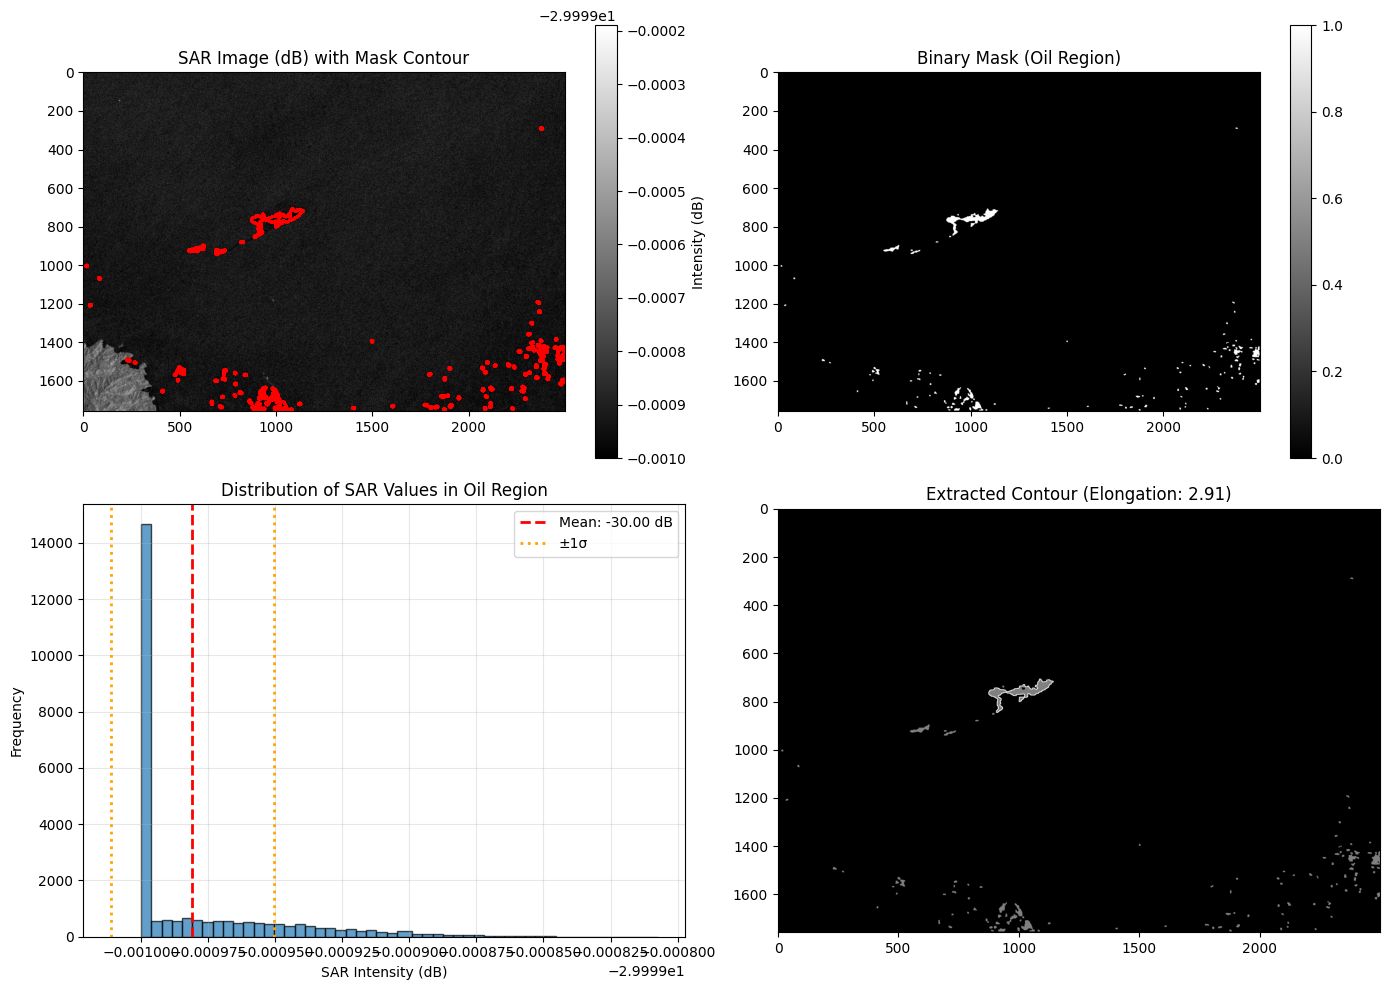


✓ Feature extraction complete!


In [39]:
# Extract radiometric features from SAR image WITHIN the mask ROI
print("--- Extracting Radiometric Features from SAR (in dB) ---")
print(f"SAR (dB) shape: {sar_db.shape}, Mask shape: {mask_bin.shape}")

# Extract SAR values only where mask is 1 (oil region)
sar_roi = sar_db[mask_bin > 0]
print(f"SAR pixels in masked region: {len(sar_roi)}")

# Filter out NaN and Inf values
sar_roi_valid = sar_roi[np.isfinite(sar_roi)]
print(f"Valid SAR pixels (no NaN/Inf): {len(sar_roi_valid)}")

if len(sar_roi_valid) == 0:
    warnings.warn("No valid SAR pixels in oil region! Skipping radiometric feature calculation.")
    mean_intensity = np.nan
    std_intensity = np.nan
    min_intensity = np.nan
    max_intensity = np.nan
else:
    mean_intensity = float(np.mean(sar_roi_valid))
    std_intensity = float(np.std(sar_roi_valid))
    min_intensity = float(np.min(sar_roi_valid))
    max_intensity = float(np.max(sar_roi_valid))

print(f"\n✓ Radiometric features extracted from SAR (within mask):")
print(f"  Mean intensity: {mean_intensity:.2f} dB")
print(f"  Std intensity: {std_intensity:.2f} dB")
print(f"  Min intensity: {min_intensity:.2f} dB")
print(f"  Max intensity: {max_intensity:.2f} dB")

# --- Also extract geometric features from the mask ---
print("\n--- Extracting Geometric Features from Mask ---")
try:
    geometric_features = extract_geometric_features(mask_bin)
    print(f"✓ Geometric features extracted:")
    print(f"  Orientation: {geometric_features.orientation:.2f}°")
    print(f"  Elongation ratio: {geometric_features.elongation_ratio:.2f}")
    print(f"  Compactness: {geometric_features.compactness:.2f}")
    print(f"  Area: {geometric_features.area_pixels} pixels")
    print(f"  Perimeter: {geometric_features.perimeter:.2f} pixels")
except Exception as e:
    print(f"✗ Error extracting geometric features: {e}")
    geometric_features = None

# --- Visualize SAR values in oil region ---
print("\n--- Visualization ---")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SAR image (dB, with mask overlay)
ax = axes[0, 0]
im = ax.imshow(sar_db, cmap='gray')
ax.contour(mask_bin, colors='red', linewidths=2)
ax.set_title('SAR Image (dB) with Mask Contour')
plt.colorbar(im, ax=ax, label='Intensity (dB)')

# Mask
ax = axes[0, 1]
im = ax.imshow(mask_bin, cmap='gray')
ax.set_title('Binary Mask (Oil Region)')
plt.colorbar(im, ax=ax)

# Histogram of SAR values in oil region (dB)
ax = axes[1, 0]
ax.hist(sar_roi_valid, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(mean_intensity, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_intensity:.2f} dB')
if std_intensity > 0:
    ax.axvline(mean_intensity - std_intensity, color='orange', linestyle=':', linewidth=2, label=f'±1σ')
    ax.axvline(mean_intensity + std_intensity, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('SAR Intensity (dB)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of SAR Values in Oil Region')
ax.legend()
ax.grid(True, alpha=0.3)

# Extracted mask (largest contour)
ax = axes[1, 1]
if geometric_features is not None:
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        mask_with_contour = mask_bin.copy()
        cv2.drawContours(mask_with_contour, [largest_contour], 0, 2, 2)
        ax.imshow(mask_with_contour, cmap='gray')
        ax.set_title(f'Extracted Contour (Elongation: {geometric_features.elongation_ratio:.2f})')
    else:
        ax.imshow(mask_bin, cmap='gray')
        ax.set_title('Mask (no contours found)')
else:
    ax.imshow(mask_bin, cmap='gray')
    ax.set_title('Mask')

plt.tight_layout()
plt.show()

print("\n✓ Feature extraction complete!")

In [40]:
# First, examine the coordinates in the NetCDF file to get valid lat/lon
print("Examining simulation file coordinates to find valid spot location...\n")

try:
    ds = Dataset(str(nc_file_path), 'r')
    
    lons = ds.variables['lon'][:]
    lats = ds.variables['lat'][:]
    
    # Get first trajectory data
    first_traj_lon = lons[0, :]
    first_traj_lat = lats[0, :]
    
    print("First trajectory coordinates:")
    print(f"  Starting point: lat={first_traj_lat[0]:.4f}, lon={first_traj_lon[0]:.4f}")
    print(f"  Ending point: lat={first_traj_lat[-1]:.4f}, lon={first_traj_lon[-1]:.4f}")
    
    # Use first point as the spot centroid
    spot_lat_actual = float(first_traj_lat[0])
    spot_lon_actual = float(first_traj_lon[0])
    
    print(f"\nUsing simulation starting point as spot location:")
    print(f"  Spot lat/lon: ({spot_lat_actual:.4f}, {spot_lon_actual:.4f})")
    
    ds.close()
    
except Exception as e:
    print(f"Error examining NetCDF: {e}")

Examining simulation file coordinates to find valid spot location...

First trajectory coordinates:
  Starting point: lat=13.3015, lon=121.5498
  Ending point: lat=13.2642, lon=121.4942

Using simulation starting point as spot location:
  Spot lat/lon: (13.3015, 121.5498)


In [47]:
def print_oil_spill_report(report):
    """
    Print a structured physics-guided oil spill classification report.
    Compatible with ClassificationReport dataclass.
    """
    line = "=" * 70

    print("\n" + line)
    print("PHYSICS-GUIDED OIL SPILL CLASSIFICATION REPORT")
    print(line)

    print(f"\nTimestamp               : {report.timestamp}")
    print(f"Final Classification    : {report.classification}")
    print(f"Confidence Score        : {report.confidence_score:.2%}")

    print("\n" + "-" * 70)
    print("GEOMETRIC FEATURES")
    print("-" * 70)
    gf = report.geometric_features
    print(f"Orientation             : {gf.orientation:.2f}°")
    print(f"Elongation Ratio        : {gf.elongation_ratio:.2f}")
    print(f"Compactness             : {gf.compactness:.2f}")
    print(f"Area                    : {gf.area_pixels} pixels")
    print(f"Perimeter               : {gf.perimeter:.2f} pixels")

    print("\n" + "-" * 70)
    print("RADIOMETRIC FEATURES")
    print("-" * 70)
    rf = report.radiometric_features
    print(f"Mean Intensity          : {rf.mean_intensity:.2f} dB")
    print(f"Std. Deviation          : {rf.std_intensity:.2f} dB")
    print(f"Minimum Intensity       : {rf.min_intensity:.2f} dB")
    print(f"Maximum Intensity       : {rf.max_intensity:.2f} dB")

    print("\n" + "-" * 70)
    print("DRIFT INFORMATION")
    print("-" * 70)
    print(f"Expected Drift Direction: {report.expected_drift_direction:.2f}°")

    print("\n" + "-" * 70)
    print("PHYSICS-BASED RULE CHECKS")
    print("-" * 70)
    rules = report.rules
    print(f"Darkness Rule           : {'PASS' if rules.darkness_pass else 'FAIL'}")
    print(f"Smoothness Rule         : {'PASS' if rules.smoothness_pass else 'FAIL'}")
    print(f"Shape Rule              : {'PASS' if rules.shape_pass else 'FAIL'}")
    print(f"Alignment Rule          : {'PASS' if rules.alignment_pass else 'FAIL'}")
    print(f"All Rules Passed        : {'YES' if rules.all_pass else 'NO'}")

    print("\n" + line + "\n")


In [48]:
# Run the physics-guided oil spill classifier
print("\n" + "="*70)
print("RUNNING PHYSICS-GUIDED OIL SPILL CLASSIFIER")
print("="*70 + "\n")

if sar_db is None or mask_bin is None:
    print("✗ SAR image or mask not available - cannot run classifier")
else:
    # Get spot centroid from the mask
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    if len(contours) == 0:
        print("✗ No contours found in mask - cannot determine spot location")
    else:
        largest_contour = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest_contour)
        
        if M['m00'] == 0:
            print("✗ Could not calculate mask centroid")
        else:
            cy = int(M['m01'] / M['m00'])
            cx = int(M['m10'] / M['m00'])
            
            # Get simulation coordinates (from the NetCDF file)
            spot_lat = spot_lat_actual
            spot_lon = spot_lon_actual
            
            print(f"Spot detected at pixel coordinates: ({cx}, {cy})")
            print(f"Using simulation coordinates: lat={spot_lat:.4f}, lon={spot_lon:.4f}\n")
            
            # Create custom configuration with RELAXED thresholds
            # Now using proper dB scale
            config = ClassifierConfig(
                DARKNESS_THRESHOLD=-18.0,      # Oil darker than -18 dB (typical: -20 to -15 dB)
                SMOOTHNESS_THRESHOLD=2.5,      # Low variation (typical: 1-3 dB)
                ELONGATION_THRESHOLD=1.5,      # Elongated shape (relaxed from 1.8)
                COMPACTNESS_THRESHOLD=1.5,     # Complex boundary (relaxed from 2.0)
                ALIGNMENT_TOLERANCE=90.0,      # INCREASED: Allow higher drift direction variation
                DRIFT_TIME_WINDOW_HOURS=2,
                POSITION_MATCH_TOLERANCE_KM=50
            )
            
            print(f"Configuration:")
            print(f"  Darkness threshold: {config.DARKNESS_THRESHOLD} dB")
            print(f"  Smoothness threshold: {config.SMOOTHNESS_THRESHOLD} dB")
            print(f"  Elongation threshold: {config.ELONGATION_THRESHOLD}")
            print(f"  Compactness threshold: {config.COMPACTNESS_THRESHOLD}")
            print(f"  Alignment tolerance: {config.ALIGNMENT_TOLERANCE}°\n")
            
            try:
                # Run classifier using SAR in dB scale
                print("Executing classifier pipeline...\n")
                report = classify_oil_spill(
                    binary_mask=mask_bin,
                    sar_image=sar_db,  # Use the dB-converted SAR image
                    nc_file_path=str(nc_file_path),
                    spot_centroid=(spot_lat, spot_lon),
                    config=config
                )
                
                # Print detailed report
                print_oil_spill_report(report)

                
                # Export results as dictionary
                results_dict = {
                    'classification': report.classification,
                    'confidence_score': report.confidence_score,
                    'geometric_features': {
                        'orientation': report.geometric_features.orientation,
                        'elongation_ratio': report.geometric_features.elongation_ratio,
                        'compactness': report.geometric_features.compactness,
                        'area_pixels': report.geometric_features.area_pixels,
                        'perimeter': report.geometric_features.perimeter
                    },
                    'radiometric_features': {
                        'mean_intensity': report.radiometric_features.mean_intensity,
                        'std_intensity': report.radiometric_features.std_intensity,
                        'min_intensity': report.radiometric_features.min_intensity,
                        'max_intensity': report.radiometric_features.max_intensity
                    },
                    'drift_direction': report.expected_drift_direction,
                    'rules': {
                        'darkness': report.rules.darkness_pass,
                        'smoothness': report.rules.smoothness_pass,
                        'shape': report.rules.shape_pass,
                        'alignment': report.rules.alignment_pass
                    }
                }
                
                print("\n✓ Classification complete!")
                print("\nResults Summary:")
                import json
                print(json.dumps(results_dict, indent=2))
                
            except Exception as e:
                print(f"\n✗ Classification failed: {e}")
                import traceback
                traceback.print_exc()


RUNNING PHYSICS-GUIDED OIL SPILL CLASSIFIER

Spot detected at pixel coordinates: (1004, 760)
Using simulation coordinates: lat=13.3015, lon=121.5498

Configuration:
  Darkness threshold: -18.0 dB
  Smoothness threshold: 2.5 dB
  Elongation threshold: 1.5
  Compactness threshold: 1.5
  Alignment tolerance: 90.0°

Executing classifier pipeline...

[STEP 1] Extracting geometric and radiometric features...
  - Geometric features: orientation=70.24°, elongation=2.91, compactness=9.31
  - Radiometric features: mean_intensity=-30.00 dB, std_intensity=0.00 dB

[STEP 2] Extracting drift direction from simulation...
  NetCDF Info: 1000 trajectories, 12 time steps
  Time range: 1682251200.00 to 1682290800.00
  First hour time: 1682251200.00 → 1682254800.00
  Selected trajectory 0
    Start (t=0): lat=13.3015°, lon=121.5498°
    End (t=1):   lat=13.2946°, lon=121.5416°
    Distance drifted: 1.17 km
    Drift direction (bearing): 229.23°
  - Expected drift direction: 229.23°

[STEP 3] Verifying ph


VISUALIZING ALIGNMENT CHECK ON ACTUAL EXTRACTED DATA

✓ Found classification report with extracted features

From SAR Image Analysis:
  Mask Orientation: 70.2°

From Simulation (1st hour):
  Drift Direction: 229.2°

Configuration:
  Alignment Tolerance: 90.0°



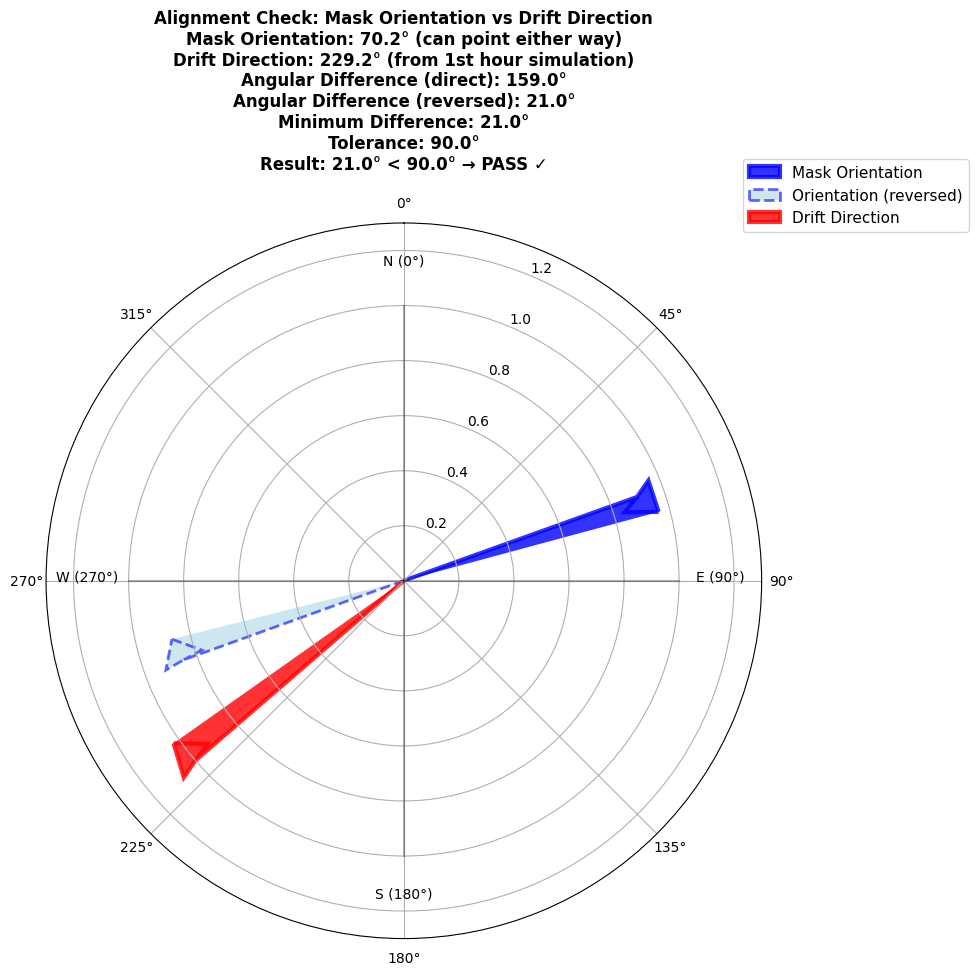


ALIGNMENT CHECK: MASK ORIENTATION vs DRIFT DIRECTION

Mask Orientation: 70.2° (from SAR image contour analysis)
  → Can point in either direction: 70.2° OR 250.2°

Drift Direction: 229.2° (from 1st hour of simulation)
  → Compass bearing: 0°=North, 90°=East, 180°=South, 270°=West

Angular Calculations:
  Direct difference:   |70.2° - 229.2°| = 159.0°
  Reversed difference: |250.2° - 229.2°| = 21.0°
  Minimum difference:  21.0°

Alignment Tolerance: 90.0°
Result: 21.0° < 90.0° → PASS ✓



In [42]:

# Visualize alignment check on ACTUAL extracted data
print("\n" + "="*70)
print("VISUALIZING ALIGNMENT CHECK ON ACTUAL EXTRACTED DATA")
print("="*70)

if 'report' in dir():
    print("\n✓ Found classification report with extracted features\n")
    
    # Get actual values from the report
    actual_orientation = report.geometric_features.orientation
    actual_drift = report.expected_drift_direction
    actual_tolerance = config.ALIGNMENT_TOLERANCE
    
    print(f"From SAR Image Analysis:")
    print(f"  Mask Orientation: {actual_orientation:.1f}°\n")
    print(f"From Simulation (1st hour):")
    print(f"  Drift Direction: {actual_drift:.1f}°\n")
    print(f"Configuration:")
    print(f"  Alignment Tolerance: {actual_tolerance:.1f}°\n")
    
    # Visualize the alignment
    visualize_alignment_check(actual_orientation, actual_drift, actual_tolerance)
    
else:
    print("\n✗ Classification report not found!")
    print("Please run the classifier cell above first.")


## Export Extracted Features to CSV

Export all extracted features in the required format for RF classifier testing.

In [43]:
import pandas as pd
from pathlib import Path

print("\n" + "=" * 70)
print("EXPORTING RAW EXTRACTED FEATURES (BEFORE LABELING) TO CSV")
print("=" * 70)

# Check if extracted features exist from the classification report
if 'report' in dir():
    print("\n✓ Found extracted features from PG classifier report")
    
    # Create raw features dataframe with only the 4 RF classifier columns
    raw_features = {
        'mean_intensity': [report.radiometric_features.mean_intensity],
        'std_intensity': [report.radiometric_features.std_intensity],
        'elongation_ratio': [report.geometric_features.elongation_ratio],
        'compactness': [report.geometric_features.compactness]
    }
    
    extracted_df = pd.DataFrame(raw_features)
    
    print("\nRaw Extracted Features (before any labeling):")
    print(extracted_df.to_string(index=False))
    
    # Determine output directory
    project_root = project_root if 'project_root' in dir() else Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    outputs_dir = project_root / 'outputs'
    
    # Create outputs directory if it doesn't exist
    outputs_dir.mkdir(exist_ok=True, parents=True)
    
    # Save raw extracted features to CSV (for RF classifier testing)
    raw_csv_path = outputs_dir / 'pg_extracted_raw_features.csv'
    extracted_df.to_csv(raw_csv_path, index=False)
    print(f"\n✓ Raw extracted features exported to: {raw_csv_path}")
    print(f"  File size: {raw_csv_path.stat().st_size} bytes")
    
    # Also export the features WITH PG labels for comparison
    print("\n" + "-" * 70)
    print("ALSO EXPORTING: Features with PG classification labels (for comparison)")
    print("-" * 70)
    
    full_features = {
        'mean_intensity': [report.radiometric_features.mean_intensity],
        'std_intensity': [report.radiometric_features.std_intensity],
        'elongation_ratio': [report.geometric_features.elongation_ratio],
        'compactness': [report.geometric_features.compactness],
        'pg_classification': [report.classification],
        'pg_confidence': [report.confidence_score]
    }
    
    full_df = pd.DataFrame(full_features)
    
    full_csv_path = outputs_dir / 'pg_extracted_features_with_labels.csv'
    full_df.to_csv(full_csv_path, index=False)
    print(f"✓ Full features with PG labels exported to: {full_csv_path}")
    
    print("\n" + "-" * 70)
    print("FILES CREATED")
    print("-" * 70)
    print("\n1. Raw Features (for RF Classifier):")
    print(extracted_df.to_string(index=False))
    print(f"   → {raw_csv_path.name}")
    
    print("\n2. Features with PG Labels (for Comparison):")
    print(full_df.to_string(index=False))
    print(f"   → {full_csv_path.name}")
    
    print("\n" + "=" * 70)
    print("✓ EXPORT COMPLETE")
    print("=" * 70)
    print(f"\nFiles saved in: {outputs_dir}")
    print("\nWorkflow:")
    print("  1. Raw features → notebook 5 RF classifier")
    print("  2. RF classifier predicts labels")
    print("  3. Compare RF predictions with PG labels")
    
else:
    print("\n✗ Classification report not found!")
    print("Please run the PG classifier feature extraction + classification cells first")


EXPORTING RAW EXTRACTED FEATURES (BEFORE LABELING) TO CSV

✓ Found extracted features from PG classifier report

Raw Extracted Features (before any labeling):
 mean_intensity  std_intensity  elongation_ratio  compactness
     -29.999981        0.00003          2.911509     9.309472

✓ Raw extracted features exported to: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\outputs\pg_extracted_raw_features.csv
  File size: 139 bytes

----------------------------------------------------------------------
ALSO EXPORTING: Features with PG classification labels (for comparison)
----------------------------------------------------------------------
✓ Full features with PG labels exported to: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\outputs\pg_extracted_features_with_labels.csv

----------------------------------------------------------------------
FILES CREATED